In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load M5 sales dataset
sales = pd.read_csv("../data/Raw/sales_train_validation.csv")

print("Sales dataset loaded successfully!")
print("Shape:", sales.shape)

print("\nFirst 5 rows:")
display(sales.head())

Sales dataset loaded successfully!
Shape: (30490, 1918)

First 5 rows:


,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


RISK ANALYSIS

Risk Statistics:
------------------------------------------------------------
Average demand: 1.13
Average demand variability: 1.5
Average coefficient of variation: 2.39
Average zero-sales percentage: 68.2 %

High-volatility items: 7623
High zero-sales items: 7621

Risk Distribution:
------------------------------------------------------------
risk_level
High Risk      28786
Medium Risk     1627
Low Risk          77
Name: count, dtype: int64

Risk Percentage:
------------------------------------------------------------
risk_level
High Risk      94.41
Medium Risk     5.34
Low Risk        0.25
Name: count, dtype: float64


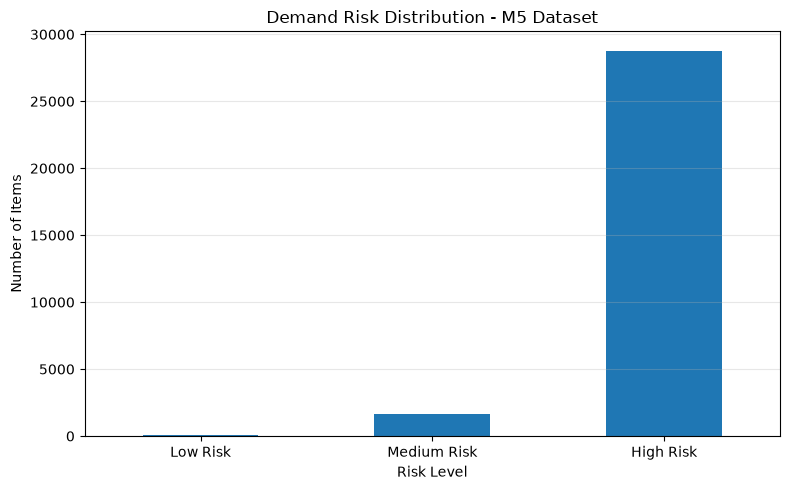

In [3]:
# ============================================================
# STEP 11: RISK ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("RISK ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Prepare item-level sales data
# ------------------------------------------------------------

sales_cols = [col for col in sales.columns if col.startswith("d_")]

risk_data = pd.DataFrame()

risk_data["item_id"] = sales["item_id"]
risk_data["total_sales"] = sales[sales_cols].sum(axis=1)
risk_data["average_sales"] = sales[sales_cols].mean(axis=1)
risk_data["std_sales"] = sales[sales_cols].std(axis=1)

# ------------------------------------------------------------
# 2. Calculate coefficient of variation
# ------------------------------------------------------------

risk_data["cv"] = np.where(
    risk_data["average_sales"] > 0,
    risk_data["std_sales"] / risk_data["average_sales"],
    np.nan
)

# ------------------------------------------------------------
# 3. Calculate zero-sales percentage
# ------------------------------------------------------------

risk_data["zero_sales_percentage"] = (
    (sales[sales_cols] == 0).sum(axis=1)
    / len(sales_cols)
) * 100

# ------------------------------------------------------------
# 4. Display risk statistics
# ------------------------------------------------------------

print("\nRisk Statistics:")
print("-" * 60)

print("Average demand:",
      round(risk_data["average_sales"].mean(), 2))

print("Average demand variability:",
      round(risk_data["std_sales"].mean(), 2))

print("Average coefficient of variation:",
      round(risk_data["cv"].mean(), 2))

print("Average zero-sales percentage:",
      round(risk_data["zero_sales_percentage"].mean(), 2), "%")

# ------------------------------------------------------------
# 5. Identify high-volatility items
# ------------------------------------------------------------

high_volatility = risk_data[
    risk_data["cv"] > risk_data["cv"].quantile(0.75)
]

print("\nHigh-volatility items:",
      len(high_volatility))

# ------------------------------------------------------------
# 6. Identify high zero-sales items
# ------------------------------------------------------------

high_zero_sales = risk_data[
    risk_data["zero_sales_percentage"] >
    risk_data["zero_sales_percentage"].quantile(0.75)
]

print("High zero-sales items:",
      len(high_zero_sales))

# ------------------------------------------------------------
# 7. Risk classification
# ------------------------------------------------------------

def classify_risk(row):

    if row["cv"] >= 1.0 or row["zero_sales_percentage"] >= 50:
        return "High Risk"

    elif row["cv"] >= 0.5 or row["zero_sales_percentage"] >= 25:
        return "Medium Risk"

    else:
        return "Low Risk"


risk_data["risk_level"] = risk_data.apply(
    classify_risk,
    axis=1
)

# ------------------------------------------------------------
# 8. Risk distribution
# ------------------------------------------------------------

risk_distribution = risk_data["risk_level"].value_counts()

print("\nRisk Distribution:")
print("-" * 60)
print(risk_distribution)

# ------------------------------------------------------------
# 9. Risk percentage
# ------------------------------------------------------------

risk_percentage = (
    risk_distribution /
    len(risk_data)
) * 100

print("\nRisk Percentage:")
print("-" * 60)
print(risk_percentage.round(2))

# ------------------------------------------------------------
# 10. Risk visualization
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

risk_distribution.reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
).plot(kind="bar")

plt.title("Demand Risk Distribution - M5 Dataset")
plt.xlabel("Risk Level")
plt.ylabel("Number of Items")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# RISK ANALYSIS
# ============================================================

sales_cols = [col for col in sales.columns if col.startswith("d_")]

risk_data = pd.DataFrame()

risk_data["item_id"] = sales["item_id"]

risk_data["total_sales"] = sales[sales_cols].sum(axis=1)

risk_data["average_sales"] = sales[sales_cols].mean(axis=1)

risk_data["std_sales"] = sales[sales_cols].std(axis=1)

risk_data["cv"] = np.where(
    risk_data["average_sales"] > 0,
    risk_data["std_sales"] / risk_data["average_sales"],
    np.nan
)

risk_data["zero_sales_percentage"] = (
    (sales[sales_cols] == 0).sum(axis=1)
    / len(sales_cols)
) * 100


print("=" * 60)
print("RISK ANALYSIS")
print("=" * 60)

print("\nAverage demand:",
      round(risk_data["average_sales"].mean(), 2))

print("Average demand variability:",
      round(risk_data["std_sales"].mean(), 2))

print("Average coefficient of variation:",
      round(risk_data["cv"].mean(), 2))

print("Average zero-sales percentage:",
      round(risk_data["zero_sales_percentage"].mean(), 2), "%")

RISK ANALYSIS

Average demand: 1.13
Average demand variability: 1.5
Average coefficient of variation: 2.39
Average zero-sales percentage: 68.2 %


In [5]:
def classify_risk(row):

    if row["cv"] >= 1.0 or row["zero_sales_percentage"] >= 50:
        return "High Risk"

    elif row["cv"] >= 0.5 or row["zero_sales_percentage"] >= 25:
        return "Medium Risk"

    else:
        return "Low Risk"


risk_data["risk_level"] = risk_data.apply(
    classify_risk,
    axis=1
)

print("\nRisk Distribution:")
print("-" * 60)
print(risk_data["risk_level"].value_counts())

print("\nRisk Percentage:")
print("-" * 60)

print(
    (risk_data["risk_level"].value_counts(normalize=True) * 100)
    .round(2)
)


Risk Distribution:
------------------------------------------------------------
risk_level
High Risk      28786
Medium Risk     1627
Low Risk          77
Name: count, dtype: int64

Risk Percentage:
------------------------------------------------------------
risk_level
High Risk      94.41
Medium Risk     5.34
Low Risk        0.25
Name: proportion, dtype: float64


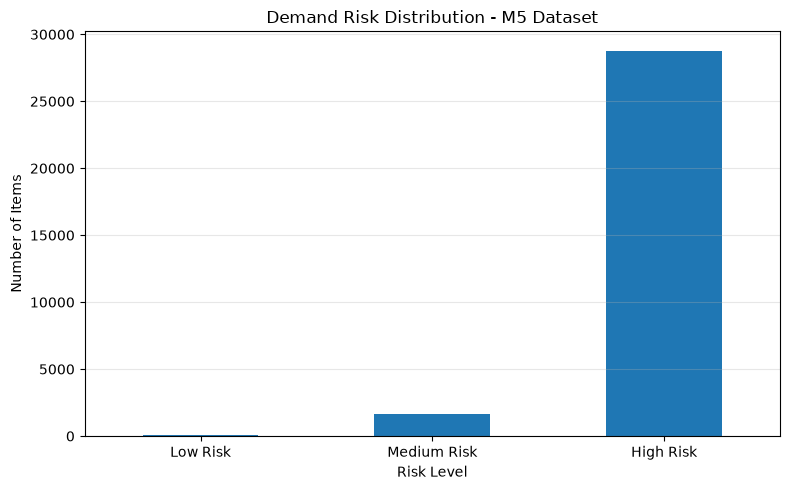

In [6]:
risk_distribution = risk_data["risk_level"].value_counts()

risk_distribution = risk_distribution.reindex(
    ["Low Risk", "Medium Risk", "High Risk"],
    fill_value=0
)

plt.figure(figsize=(8, 5))

risk_distribution.plot(kind="bar")

plt.title("Demand Risk Distribution - M5 Dataset")
plt.xlabel("Risk Level")
plt.ylabel("Number of Items")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()